In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from ydata_profiling import ProfileReport
import pickle
import random
import itertools

pd.options.display.max_columns = None
pd.options.display.max_colwidth = 50

data_folder = "../data/"
images_folder = "../../images/"
pipelines_folder = "../pipelines/"
df_total = pd.read_csv(os.path.join(data_folder, 'items_phase_1.csv'))
df_train = pd.read_csv(os.path.join(data_folder, 'items_train.csv'))
df_task_1 = pd.read_csv(os.path.join(data_folder, 'task_1.csv'))

# Notebook `items_phase_1.csv`

In [2]:
# profile = ProfileReport(df_total, title="items_phase_1", explorative=True)
# profile.to_notebook_iframe()

In [3]:
print("Length of dataset:", len(df_total))

Length of dataset: 199835


In [4]:
df_total.sample(2)

,itemId,price,colorTagIdsString,departmentIds,brandEditionTagId,title,description,geo
24894,646498,49.0,"231,806","['1', '11']",NaN,Шапка с козирка New Era,New Era Шапка с козирка Team Colour Block T 12...,bg
118790,609461,409.0,37645,['1'],NaN,Şlapi Birkenstock,Şlapi Birkenstock Madrid Bs 40731 Alb,ro


## Key takeaway
- missingy se musi resit u:
    - description (3%)
    - brandEditionTagId (99.8%) - to je asi target?
    - colorTagIdsString (3.1%)
---
# Notebook `task_1.csv`
- kazdy radek je jedna skupina se sloupci item - item4(to jsou id do items_phase_1.csv - itemId)
- Kazdy 

In [5]:
print("Length of dataset:", len(df_task_1))

Length of dataset: 15000


In [6]:
# profile = ProfileReport(df_task_1, title="task_1", explorative=True)
# profile.to_notebook_iframe()

In [7]:
df_task_1.head()

,item1,item2,item3,item4,item5
0,130622,292253,463442,483968,1253745
1,82627,388496,553738,638400,884327
2,46130,333489,644448,848154,1178149
3,150796,248537,742067,1206230,1280786
4,76610,196894,345145,620255,932761


---
# Dataset `items_train.csv`
- obsahuje toho min, vim ze ma stejny hodnoty v departmentIds


In [8]:
print("Total records:", len(df_train))
print("Total null values:\n", df_train.isnull().sum())

Total records: 928234
Total null values:
 itemId                    0
price                     0
colorTagIdsString     27834
departmentIds             0
brandEditionTagId    925518
title                     0
description           35473
geo                       0
label                     0
dtype: int64


In [9]:
df_train.sample(2)

,itemId,price,colorTagIdsString,departmentIds,brandEditionTagId,title,description,geo,label
701064,88381,40.9,"771,772",[],NaN,Tenisice za nogomet Joma,Tenisice za nogomet Joma Score Firm Ground SCO...,hr,29631
173147,612920,86.9,"770,775",['1'],NaN,Τσάντα Guess,Guess Τσάντα HWWW92 19210 Ροζ,gr,18259


In [10]:
# profile = ProfileReport(df_train, title="task_1", explorative=True)
# profile.to_notebook_iframe()


--- 
## Ukazka obrazku + kontrola zda mame vsechny

=== Ukazka ===
itemId                                        225269
price                                          85.95
colorTagIdsString                               6460
departmentIds                                  ['1']
brandEditionTagId                                NaN
title                                   Šľapky Guess
description          Šľapky Guess FLJRLL LEA19 Hnedá
geo                                               sk
label                                          38980
Name: 79, dtype: object



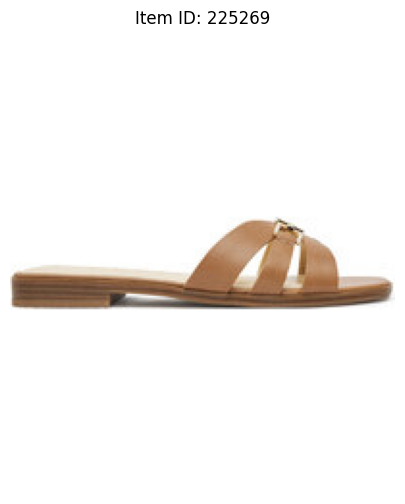

In [11]:
import os
import matplotlib.pyplot as plt
from PIL import Image

first_row = df_train.iloc[79] 
item_id = first_row['itemId']

print("=== Ukazka ===")
print(first_row)
print("===============================\n")

img_path = os.path.join(images_folder, f"{item_id}.jpg")

img = Image.open(img_path).convert("RGB")

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')
plt.title(f"Item ID: {item_id}")
plt.show()

In [12]:
import os
import pandas as pd

def find_missing_images(df, images_folder, item_col='itemId'):
    print("🔍 Analyzuji dataset a složku s obrázky...")
    
    expected_ids = set(df[item_col].astype(str))
    print(f"📊 Tabulka vyžaduje: {len(expected_ids)} unikátních obrázků.")
    
    try:
        available_files = [f[:-4] for f in os.listdir(images_folder) if f.endswith('.jpg')]
        available_ids = set(available_files)
        print(f"📂 Na disku nalezeno: {len(available_ids)} .jpg souborů.")
    except FileNotFoundError:
        print(f"❌ Chyba: Složka '{images_folder}' neexistuje!")
        return []

    missing_ids = expected_ids - available_ids
    
    if len(missing_ids) == 0:
        print("🎉 Perfektní! Úplně každý záznam v tabulce má svůj fyzický obrázek.")
    else:
        print(f"⚠️ POZOR: Chybí přesně {len(missing_ids)} obrázků!")
        print(f"Ukázka chybějících ID: {list(missing_ids)[:5]}")
        
    return list(missing_ids)

chybejici_obrazky = find_missing_images(df_total, images_folder)
chybejici_obrazky = find_missing_images(df_train, images_folder)

🔍 Analyzuji dataset a složku s obrázky...
📊 Tabulka vyžaduje: 199835 unikátních obrázků.
📂 Na disku nalezeno: 1325907 .jpg souborů.
🎉 Perfektní! Úplně každý záznam v tabulce má svůj fyzický obrázek.
🔍 Analyzuji dataset a složku s obrázky...
📊 Tabulka vyžaduje: 928234 unikátních obrázků.
📂 Na disku nalezeno: 1325907 .jpg souborů.
🎉 Perfektní! Úplně každý záznam v tabulce má svůj fyzický obrázek.
🔍 Analyzuji dataset a složku s obrázky...
📊 Tabulka vyžaduje: 928234 unikátních obrázků.
📂 Na disku nalezeno: 1325907 .jpg souborů.
🎉 Perfektní! Úplně každý záznam v tabulce má svůj fyzický obrázek.
📂 Na disku nalezeno: 1325907 .jpg souborů.
🎉 Perfektní! Úplně každý záznam v tabulce má svůj fyzický obrázek.


---
# Vycisteni dat 
- prevod na spolecnou menu 
- normalizace meny v danem geo uzemi
- doplneni null hodnot
- null ve sloupci `colorTagIdString` muzu nahradit 0 
- `colorTagIdString` a `departmentIds` je potreba roztrhnout - obsahuji vice hodnot oddelenych carkou

## Tvorba preprocessing pipeline

In [13]:
df_total[df_total["brandEditionTagId"] == 0]

,itemId,price,colorTagIdsString,departmentIds,brandEditionTagId,title,description,geo


In [14]:
df_train.columns

Index(['itemId', 'price', 'colorTagIdsString', 'departmentIds',
       'brandEditionTagId', 'title', 'description', 'geo', 'label'],
      dtype='object')

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from PriceGeoTransformer import PriceGeoTransformer
from DepartmentIdsTransformer import DepartmentIdsCleaner
import numpy as np


input_unknown_cols = ["description","title"]
input_unknown_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value="Unknown")),
])



# Pro textové IDčka (barvy) dáme prázdný string
imput_empty_string_cols = ['colorTagIdsString']
input_empty_string_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value="")),
])

imput_zero_cols = ["brandEditionTagId"]
input_zero_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
])


# prevadi na stejny format jako jsou barvy - cisla oddelena carkou 
department_features = ['departmentIds']
department_transformer = Pipeline(steps=[
    ('DepartmentIdsCleaner', DepartmentIdsCleaner())
])

# impute missing geo and convert back to pandas
imputer_step = ColumnTransformer(
    transformers=[
        ('geo_imp', SimpleImputer(strategy='constant', fill_value='<UNK>'), ['geo']),
        ('price_imp', SimpleImputer(strategy='median'), ['price'])
    ], 
    remainder='passthrough',
    verbose_feature_names_out=False 
).set_output(transform="pandas")

categorical_features = ['geo',"price"]
categorical_transformer = Pipeline(steps=[
    ("imputer", imputer_step),
    ('PriceGeoTransformer', PriceGeoTransformer())
])


# Combine preprocessing for numeric and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('zero', input_zero_transformer, imput_zero_cols),
        ('unknown', input_unknown_transformer, input_unknown_cols),
        ('geo', categorical_transformer, categorical_features),
        ('department', department_transformer, department_features)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

preprocessor.set_output(transform="pandas")



pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

X_train = df_train.drop(columns=['label'])
y_train = df_train['label']

X_train_transformed = pipeline.fit_transform(X_train)
df_train_transformed = X_train_transformed.copy()
df_train_transformed['label'] = y_train.values
df_total_transformed = pipeline.transform(df_total)

In [16]:
pickle.dump(pipeline, open(os.path.join(pipelines_folder, 'preprocessing.pkl'), 'wb'))

In [17]:
# find_missing_images(df_total_transformed, images_folder)
find_missing_images(df_train_transformed, images_folder)

🔍 Analyzuji dataset a složku s obrázky...
📊 Tabulka vyžaduje: 928234 unikátních obrázků.
📂 Na disku nalezeno: 1325907 .jpg souborů.
🎉 Perfektní! Úplně každý záznam v tabulce má svůj fyzický obrázek.
📂 Na disku nalezeno: 1325907 .jpg souborů.
🎉 Perfektní! Úplně každý záznam v tabulce má svůj fyzický obrázek.


[]

## Příprava pro PyTorch dataset - Vocabulary pro transformaci kategorií
- PyTorch bude použit na vytvoření embeddingů sloupců s více kategorijema a na kategorické sloupce
- PyTorch umí totiž lépe tvořit řídké matice
- Vytvoříme si mappingy pro jednotlivé kategorie...

In [18]:
from GlamiDatasetVocabulary import GlamiVocabularyManager
vocab_manager = GlamiVocabularyManager() # vytvori vsechny potrebne mappingy kategorii do ciselnych hodnot
vocab_manager.fit(df_total_transformed)
vocab_manager.save()

## Tvorba embeddingů obrázků

In [19]:
import torch
from transformers import CLIPProcessor, CLIPVisionModel
from PIL import Image
import os
from tqdm import tqdm # Pro hezký progress bar

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("🚀 Běžíme na MPS!")
else:
    device = torch.device("cpu")
    print("⚠️ Běžíme na CPU.")

🚀 Běžíme na MPS!


In [20]:
def create_and_save_clip_embeddings(image_dir, item_ids, save_path="../artifacts/embeddings/clip_image.pt", batch_size=128):
    item_ids = list(item_ids)
    
    model_id = "openai/clip-vit-base-patch32"
    print(f"Načítám model {model_id}...")
    processor = CLIPProcessor.from_pretrained(model_id)
    model = CLIPVisionModel.from_pretrained(model_id).to(device)
    model.eval() # Přepneme do módu vyhodnocování

    embeddings_dict = {}
    valid_ids = []
    images_to_process = []

    print("Připravuji obrázky...")
    
    # processing images
    for i in tqdm(range(0, len(item_ids), batch_size)):
        batch_ids = item_ids[i:i + batch_size]
        batch_images = []
        batch_valid_ids = []

        # Načteme obrázky v dávce
        for item_id in batch_ids:
            img_path = os.path.join(image_dir, f"{item_id}.jpg")
            try:
                img = Image.open(img_path).convert("RGB")
                batch_images.append(img)
                batch_valid_ids.append(str(item_id))
            except Exception:
                print("Missing image for item_id:", item_id)


        if not batch_images:
            continue

        # 4. Provedení samotné extrakce na čipu
        with torch.no_grad(): # Šetří paměť, nechceme počítat gradienty
            inputs = processor(images=batch_images, return_tensors="pt").to(device)
            outputs = model(**inputs)
            image_embeds = outputs.pooler_output 

            # 5. Uložení do slovníku (přesuneme zpět na CPU, ať neplníme GPU paměť)
            image_embeds = image_embeds.cpu()
            for idx, i_id in enumerate(batch_valid_ids):
                embeddings_dict[i_id] = image_embeds[idx]

    print(f"Ukládám {len(embeddings_dict)} embeddingů do {save_path}...")
    torch.save(embeddings_dict, save_path)
    print("Hotovo! 🎉")
    
    return embeddings_dict

In [21]:
df_task_1

,item1,item2,item3,item4,item5
0,130622,292253,463442,483968,1253745
1,82627,388496,553738,638400,884327
2,46130,333489,644448,848154,1178149
3,150796,248537,742067,1206230,1280786
4,76610,196894,345145,620255,932761
...,...,...,...,...,...
14995,155554,524218,1124026,1180971,1245961
14996,2182,142647,528017,744044,966164
14997,360650,831549,941406,1002011,1225666
14998,481664,1021759,1123392,1272187,1283135


In [22]:
import os
import torch

os.environ["HF_HUB_OFFLINE"] = "1"
df_total
print("Připravuji CLIP embeddingy...")
item_ids_list = df_train_transformed['itemId'].unique().tolist()
item_ids_total = df_total_transformed['itemId'].unique().tolist()
item_ids_list = list(set(item_ids_list) | set(item_ids_total))
embeddings_path = "../artifacts/embeddings/clip_image.pt"

# Chytrá kontrola: nebudeme to počítat znovu, pokud už to máme!
if os.path.exists(embeddings_path):
    print("Načítám hotové embeddingy z disku (blesková akce)...")
    clip_embeddings_dict = torch.load(embeddings_path)
else:
    print("Soubor nenalezen. Žhavím Apple M4 Pro a jdu počítat z obrázků...")
    # Tady zavoláme tu funkci z minula!
    clip_embeddings_dict = create_and_save_clip_embeddings(
        image_dir=images_folder,
        item_ids=item_ids_list, 
        save_path=embeddings_path, 
        batch_size=128 # M4 Pro zvládne velké batche s přehledem
    )

print(f"Máme {len(clip_embeddings_dict)} vektorů obrázků!")

Připravuji CLIP embeddingy...
Načítám hotové embeddingy z disku (blesková akce)...
Máme 1128069 vektorů obrázků!
Máme 1128069 vektorů obrázků!


## PyTorch Dataset


--- 


## Tvorba siamese datasetu
- dataset obsahuje páry z originálního datasetu teré mají jako label 1 pokud mají stejné labely uvitř páru, jinak 0
- create_balanced_pairs jich vytvori tolik aby byly vyvazene labely 

In [23]:
# ── Item-level split: hold out 20% of LABELS for validation ──────────────────
# The key fix: if the same items can appear in both train and val pairs,
# the model memorises item embeddings and val F1 inflates to ~0.99.
# By splitting on LABELS (not rows), no item from a val label ever appears
# in a training pair → honest generalisation signal.
from collections import defaultdict
import random as rnd

rnd.seed(0)
all_labels = df_train['label'].unique().tolist()
rnd.shuffle(all_labels)

val_label_set   = set(all_labels[:int(0.20 * len(all_labels))])
train_label_set = set(all_labels[int(0.20 * len(all_labels)):])

df_train_split = df_train[df_train['label'].isin(train_label_set)].reset_index(drop=True)
df_val_split   = df_train[df_train['label'].isin(val_label_set)].reset_index(drop=True)

print(f"Train items (80% of labels): {len(df_train_split):,}  |  {len(train_label_set):,} labels")
print(f"Val   items (20% of labels): {len(df_val_split):,}    |  {len(val_label_set):,} labels")
print(f"Item overlap between splits: "
      f"{len(set(df_train_split.itemId) & set(df_val_split.itemId))}  (must be 0)")

Train items (80% of labels): 740,960  |  121,896 labels
Val   items (20% of labels): 187,274    |  30,474 labels
Item overlap between splits: 0  (must be 0)

Val   items (20% of labels): 187,274    |  30,474 labels
Item overlap between splits: 0  (must be 0)


# Hard Negative Mining v2: CLIP Image + Text Embedding Similarity

**Problem:** Current negatives are hard based on *metadata* (dept, geo, price) but not on *embedding similarity*.  
The model fails on items whose embeddings are close but belong to different labels — same-looking / same-sounding, different products.

**Solution:** Mine pairs where the **combined** (image + text) cosine similarity is high but `label_A ≠ label_B`.

**Combined similarity** = mean of:
- `cosine_sim(image_emb_A, image_emb_B)` — visual similarity  
- `cosine_sim(text_emb_A, text_emb_B)` — title+description semantic similarity

Items that score high on **both** are the true confusers for the siamese model.

In [24]:
import torch
import torch.nn.functional as F
import numpy as np
from tqdm.auto import tqdm

# ── Load CLIP image embeddings ────────────────────────────────────────────────
print("Loading CLIP image embeddings...")
clip_emb_raw = torch.load("../artifacts/embeddings/clip_image.pt", map_location="cpu")
sample_key = next(iter(clip_emb_raw))
print(f"  {len(clip_emb_raw):,} image embeddings  |  key type: {type(sample_key).__name__}  |  dim: {clip_emb_raw[sample_key].shape[0]}")

# ── Load text embeddings ──────────────────────────────────────────────────────
print("Loading text embeddings...")
text_emb_raw = torch.load("../artifacts/embeddings/text_multilingual.pt", map_location="cpu")
sample_key_t = next(iter(text_emb_raw))
print(f"  {len(text_emb_raw):,} text embeddings   |  key type: {type(sample_key_t).__name__}  |  dim: {text_emb_raw[sample_key_t].shape[0]}")

def _get_img_emb(item_id):
    v = clip_emb_raw.get(item_id)
    if v is None:
        v = clip_emb_raw.get(str(item_id))
    return v

def _get_txt_emb(item_id):
    v = text_emb_raw.get(str(item_id))
    if v is None:
        v = text_emb_raw.get(item_id)
    return v

def build_emb_matrices(df_split, split_name):
    ids_int = df_split['itemId'].tolist()
    ids_with_emb = [
        iid for iid in ids_int
        if _get_img_emb(iid) is not None and _get_txt_emb(iid) is not None
    ]
    print(f"\n  [{split_name}] items with both embeddings: {len(ids_with_emb):,} / {len(ids_int):,}")
    img_mat = F.normalize(torch.stack([_get_img_emb(iid) for iid in ids_with_emb]).float(), dim=1)
    txt_mat = F.normalize(torch.stack([_get_txt_emb(iid) for iid in ids_with_emb]).float(), dim=1)
    id_to_lbl = df_split.set_index('itemId')['label'].to_dict()
    print(f"  Image matrix : {img_mat.shape}  |  Text matrix : {txt_mat.shape}")
    return ids_with_emb, img_mat, txt_mat, id_to_lbl

# ── Train split ───────────────────────────────────────────────────────────────
train_ids_with_emb, img_matrix, txt_matrix, id_to_label_train = build_emb_matrices(df_train_split, "train")

# ── Val split ─────────────────────────────────────────────────────────────────
val_ids_with_emb, img_matrix_val, txt_matrix_val, id_to_label_val = build_emb_matrices(df_val_split, "val")


Loading CLIP image embeddings...
  1,128,069 image embeddings  |  key type: str  |  dim: 768
Loading text embeddings...
  1,128,069 image embeddings  |  key type: str  |  dim: 768
Loading text embeddings...
  1,128,069 text embeddings   |  key type: str  |  dim: 512
  1,128,069 text embeddings   |  key type: str  |  dim: 512

  [train] items with both embeddings: 740,960 / 740,960

  [train] items with both embeddings: 740,960 / 740,960
  Image matrix : torch.Size([740960, 768])  |  Text matrix : torch.Size([740960, 512])
  Image matrix : torch.Size([740960, 768])  |  Text matrix : torch.Size([740960, 512])

  [val] items with both embeddings: 187,274 / 187,274

  [val] items with both embeddings: 187,274 / 187,274
  Image matrix : torch.Size([187274, 768])  |  Text matrix : torch.Size([187274, 512])
  Image matrix : torch.Size([187274, 768])  |  Text matrix : torch.Size([187274, 512])


In [28]:
def mine_embedding_hard_negatives(
    img_matrix,
    txt_matrix,
    item_ids,
    id_to_label,
    n_pairs      = 7000000,
    sim_lo       = 0.8,
    sim_hi       = 1,
    easy_prob    = 0.01,   # chance to accept a pair BELOW sim_lo (easy negative)
    batch_size   = 1_000,
    random_state = 42,
):
    """
    Mine hard negative pairs (sim >= sim_lo, different label).
    With probability `easy_prob`, also accept easy negatives (sim < sim_lo)
    so the dataset contains a small fraction of easy examples too.
    """
    rng = np.random.default_rng(random_state)
    N   = len(item_ids)
    order = rng.permutation(N)
    item_ids_arr = np.array(item_ids)

    hard_pairs = []
    n_easy_accepted = 0
    n_batches  = (N + batch_size - 1) // batch_size

    pbar = tqdm(total=n_pairs, desc="Mining hard-neg pairs", unit="pair")

    for bi in range(n_batches):
        if len(hard_pairs) >= n_pairs:
            break
        a_idx  = order[bi * batch_size : (bi + 1) * batch_size]
        a_img  = img_matrix[a_idx]
        a_txt  = txt_matrix[a_idx]
        a_ids  = item_ids_arr[a_idx]

        rest_idx = np.concatenate([order[:bi * batch_size], order[(bi + 1) * batch_size:]])
        if len(rest_idx) > 8_000:
            rest_idx = rng.choice(rest_idx, 8_000, replace=False)
        if len(rest_idx) == 0:
            continue

        r_img = img_matrix[rest_idx]
        r_txt = txt_matrix[rest_idx]
        r_ids = item_ids_arr[rest_idx]

        img_sim = torch.mm(a_img, r_img.T).numpy()
        txt_sim = torch.mm(a_txt, r_txt.T).numpy()
        combined_sim = (img_sim + txt_sim) * 0.5

        # hard candidates: in [sim_lo, sim_hi]
        hard_mask = (combined_sim >= sim_lo) & (combined_sim <= sim_hi)
        # easy candidates: below sim_lo — accepted with easy_prob
        easy_mask = (combined_sim < sim_lo) & (rng.random(combined_sim.shape) < easy_prob)
        accept_mask = hard_mask | easy_mask

        a_pos, r_pos = np.where(accept_mask)

        found_before = len(hard_pairs)
        for ai, ri in zip(a_pos, r_pos):
            id1 = int(a_ids[ai]);  id2 = int(r_ids[ri])
            l1  = id_to_label.get(id1);  l2 = id_to_label.get(id2)
            if l1 is not None and l2 is not None and l1 != l2:
                hard_pairs.append((id1, id2, 0))
                if not hard_mask[ai, ri]:
                    n_easy_accepted += 1

        pbar.update(len(hard_pairs) - found_before)

    pbar.close()
    df_hard = pd.DataFrame(hard_pairs[:n_pairs], columns=['item_id_1', 'item_id_2', 'is_duplicate'])
    df_hard = df_hard.drop_duplicates(subset=['item_id_1', 'item_id_2']).reset_index(drop=True)
    easy_pct = 100 * n_easy_accepted / max(len(df_hard), 1)
    print(f"\nMined {len(df_hard):,} unique hard negatives  |  easy pairs included: {n_easy_accepted:,} ({easy_pct:.1f}%)")
    return df_hard


def mine_hard_positives(
    img_matrix,
    txt_matrix,
    item_ids,
    id_to_label,
    n_pairs      = 400_000,
    sim_hi       = 0.85,   # pairs BELOW this are "hard" positives
    easy_prob    = 0.01,   # chance to accept a pair ABOVE sim_hi (easy positive)
    random_state = 42,
):
    """
    Hard positives: same-label pairs with lowest combined cosine similarity (< sim_hi).
    With probability `easy_prob`, also accept easy positives (sim >= sim_hi)
    so the dataset contains a small fraction of easy examples too.
    """
    rng = np.random.default_rng(random_state)
    item_ids_arr = np.array(item_ids)

    from collections import defaultdict
    label_to_idx = defaultdict(list)
    for idx, iid in enumerate(item_ids):
        lbl = id_to_label.get(iid)
        if lbl is not None:
            label_to_idx[lbl].append(idx)

    multi_labels = [idxs for idxs in label_to_idx.values() if len(idxs) >= 2]
    rng.shuffle(multi_labels)

    hard_pos = []
    n_easy_accepted = 0
    pbar = tqdm(total=n_pairs, desc=f"Mining hard-pos pairs (sim < {sim_hi})", unit="pair")

    for idxs in multi_labels:
        if len(hard_pos) >= n_pairs:
            break
        idxs = np.array(idxs)

        g_img = img_matrix[idxs]
        g_txt = txt_matrix[idxs]
        img_sim = torch.mm(g_img, g_img.T).numpy()
        txt_sim = torch.mm(g_txt, g_txt.T).numpy()
        combined = (img_sim + txt_sim) * 0.5
        k = len(idxs)

        # collect all upper-triangle pairs, tag each as hard or easy
        pairs_sim = []
        for a in range(k):
            for b in range(a + 1, k):
                s = combined[a, b]
                is_hard = s < sim_hi
                is_easy_accepted = (not is_hard) and (rng.random() < easy_prob)
                if is_hard or is_easy_accepted:
                    pairs_sim.append((s, a, b, is_hard))

        if not pairs_sim:
            continue

        # sort: hard pairs first (lowest sim), easy pairs appended at end
        pairs_sim.sort(key=lambda x: (not x[3], x[0]))

        found_before = len(hard_pos)
        for s, a, b, is_hard in pairs_sim:
            id1, id2 = int(item_ids_arr[idxs[a]]), int(item_ids_arr[idxs[b]])
            hard_pos.append((id1, id2, 1))
            if not is_hard:
                n_easy_accepted += 1
            if len(hard_pos) >= n_pairs:
                break

        pbar.update(len(hard_pos) - found_before)

    pbar.close()
    df_hp = pd.DataFrame(hard_pos[:n_pairs], columns=['item_id_1', 'item_id_2', 'is_duplicate'])
    df_hp = df_hp.drop_duplicates(subset=['item_id_1', 'item_id_2']).reset_index(drop=True)
    easy_pct = 100 * n_easy_accepted / max(len(df_hp), 1)
    print(f"Mined {len(df_hp):,} unique hard positives  |  easy pairs included: {n_easy_accepted:,} ({easy_pct:.1f}%)")
    return df_hp


# ── Mine for train ────────────────────────────────────────────────────────────
print("=== TRAIN ===")
hard_negs_emb = mine_embedding_hard_negatives(
    img_matrix, txt_matrix, train_ids_with_emb, id_to_label_train,
    n_pairs=1_100_000, sim_lo=0.9, sim_hi=1, easy_prob=0.0001, batch_size=1_000, random_state=42,
)

hard_pos_train = mine_hard_positives(
    img_matrix, txt_matrix, train_ids_with_emb, id_to_label_train,
    n_pairs=400_000, sim_hi=0.85, easy_prob=0.01, random_state=42,
)

# ── Mine for val ──────────────────────────────────────────────────────────────
print("\n=== VAL ===")
hard_negs_val = mine_embedding_hard_negatives(
    img_matrix_val, txt_matrix_val, val_ids_with_emb, id_to_label_val,
    n_pairs=300_000, sim_lo=0.9, sim_hi=1, easy_prob=0.0001, batch_size=1_000, random_state=43,
)

hard_pos_val = mine_hard_positives(
    img_matrix_val, txt_matrix_val, val_ids_with_emb, id_to_label_val,
    n_pairs=100_000, sim_hi=0.85, easy_prob=0.01, random_state=43,
)


=== TRAIN ===


Mining hard-neg pairs:   0%|          | 0/1100000 [00:00<?, ?pair/s]


Mined 1,100,000 unique hard negatives  |  easy pairs included: 149,732 (13.6%)


Mining hard-pos pairs (sim < 0.85):   0%|          | 0/400000 [00:00<?, ?pair/s]

Mined 400,000 unique hard positives  |  easy pairs included: 36,882 (9.2%)

=== VAL ===


Mining hard-neg pairs:   0%|          | 0/300000 [00:00<?, ?pair/s]


Mined 300,000 unique hard negatives  |  easy pairs included: 42,449 (14.1%)


Mining hard-pos pairs (sim < 0.85):   0%|          | 0/100000 [00:00<?, ?pair/s]

Mined 100,000 unique hard positives  |  easy pairs included: 9,000 (9.0%)


In [26]:
TRAIN_OUT = "../artifacts/pairs/train_pairs.csv"
VAL_OUT   = "../artifacts/pairs/val_pairs.csv"

import random as _rnd

def assemble_split(hard_pos_df, hard_neg_df, neg_ratio=3, random_state=42):
    """
    Combine hard positives and hard negatives.
    Negatives are capped at neg_ratio × len(positives) to stay balanced.
    """
    n_pos  = len(hard_pos_df)
    n_neg  = min(len(hard_neg_df), n_pos * neg_ratio)
    neg_sample = hard_neg_df.sample(n=n_neg, random_state=random_state)
    df = pd.concat([hard_pos_df, neg_sample], ignore_index=True)
    df = df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    return df

train_final = assemble_split(hard_pos_train, hard_negs_emb, neg_ratio=3, random_state=42)
val_final   = assemble_split(hard_pos_val,   hard_negs_val,  neg_ratio=3, random_state=43)

train_final.to_csv(TRAIN_OUT, index=False)
val_final.to_csv(VAL_OUT,   index=False)

print(f"Train: {len(train_final):,}  |  pos rate {train_final.is_duplicate.mean():.1%}")
print(f"  hard positives : {len(hard_pos_train):,}  (low cosine-sim same-label pairs)")
print(f"  hard negatives : {(train_final.is_duplicate == 0).sum():,}  (high cosine-sim diff-label pairs)")
print()
print(f"Val  : {len(val_final):,}  |  pos rate {val_final.is_duplicate.mean():.1%}")
print(f"  hard positives : {len(hard_pos_val):,}  (low cosine-sim same-label pairs)")
print(f"  hard negatives : {(val_final.is_duplicate == 0).sum():,}  (high cosine-sim diff-label pairs)")
print()
print(f"Saved → {TRAIN_OUT}  ✓")
print(f"Saved → {VAL_OUT}  ✓")


Train: 1,500,000  |  pos rate 26.7%
  hard positives : 400,000  (low cosine-sim same-label pairs)
  hard negatives : 1,100,000  (high cosine-sim diff-label pairs)

Val  : 400,000  |  pos rate 25.0%
  hard positives : 100,000  (low cosine-sim same-label pairs)
  hard negatives : 300,000  (high cosine-sim diff-label pairs)

Saved → train_pairs_improved.csv  ✓
Saved → val_pairs_improved.csv  ✓


=== TRAIN samples ===


/var/folders/wz/x7xqj0yj6ls_367syhygxjn40000gn/T/ipykernel_8840/3220271784.py:64: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/wz/x7xqj0yj6ls_367syhygxjn40000gn/T/ipykernel_8840/3220271784.py:64: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


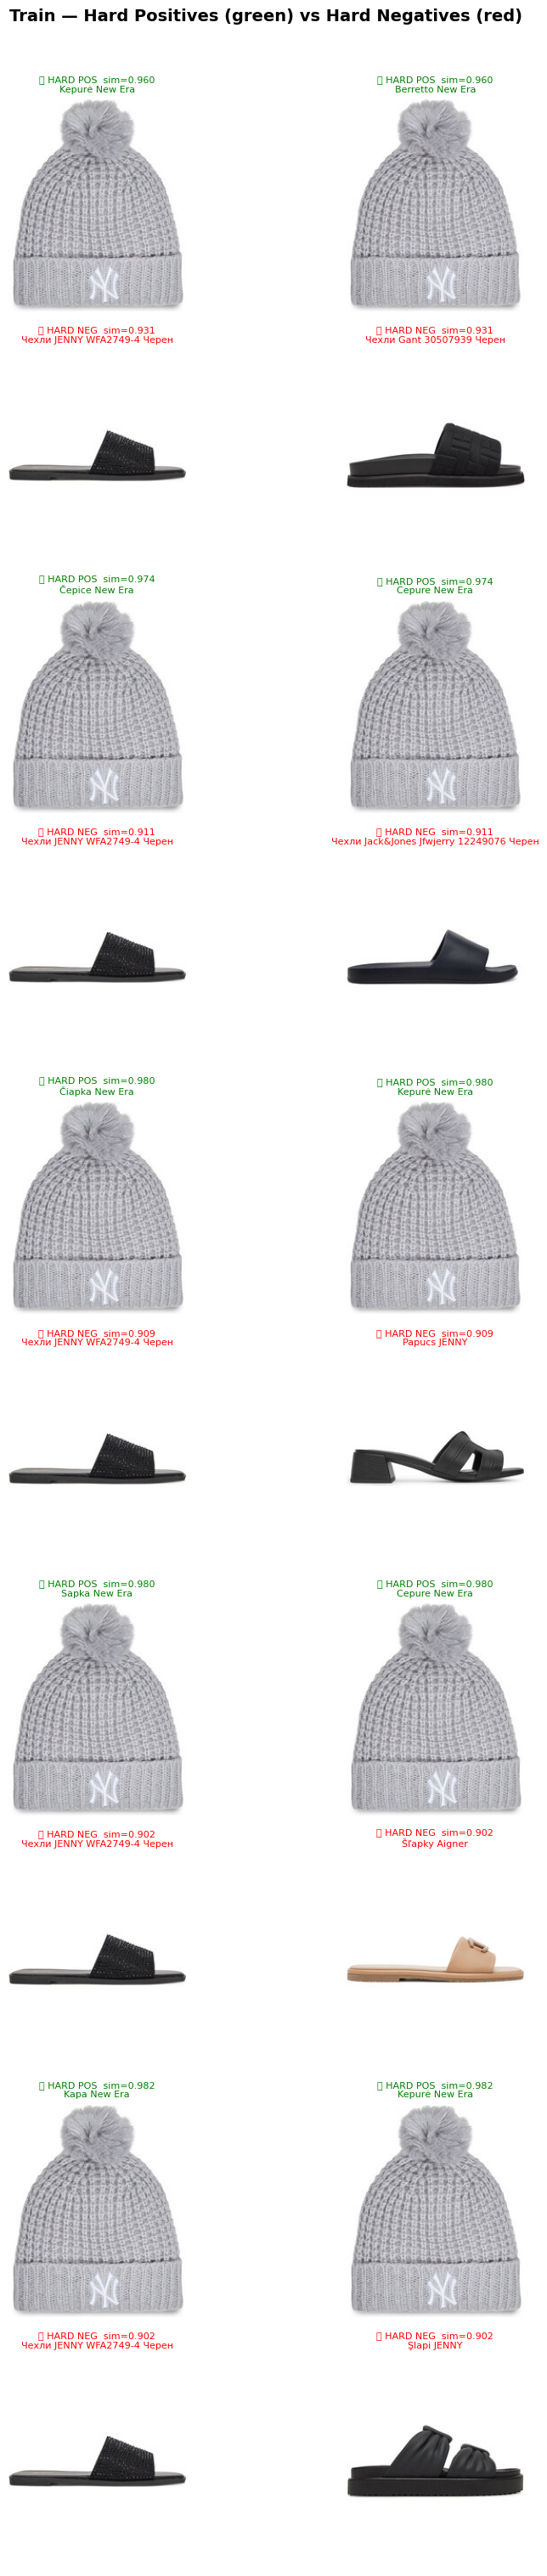

=== VAL samples ===


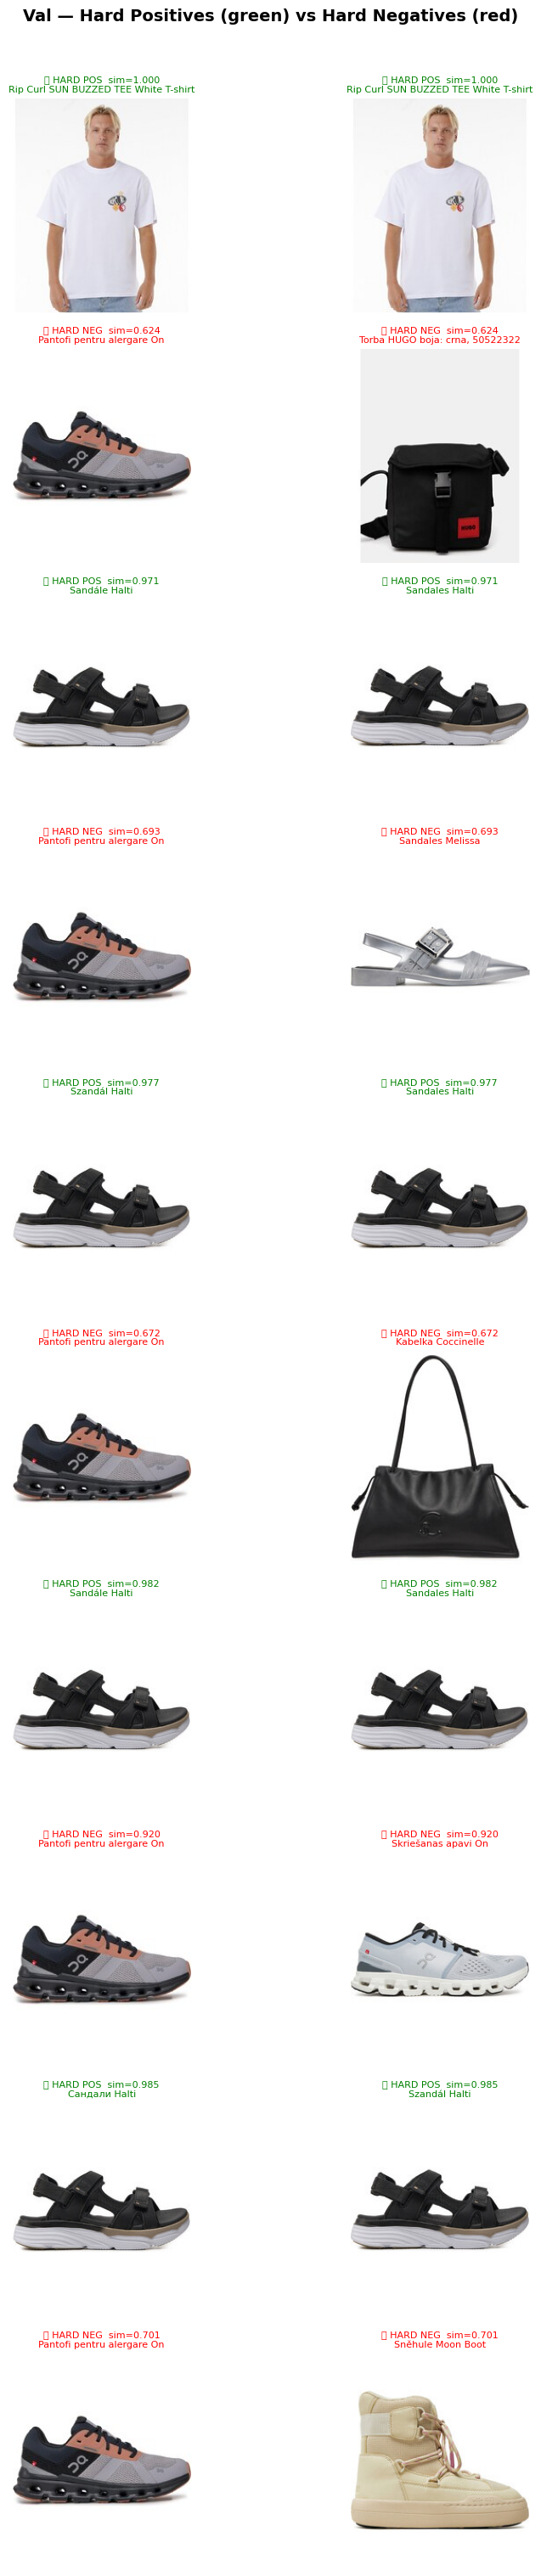

In [27]:

# ── Sanity check: visualise sample hard positives and hard negatives ──────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import os

def show_pair_samples(pos_df, neg_df, item_df, n_samples=5, title="Sanity check"):
    """
    Show n_samples hard-positive pairs (top rows) and n_samples hard-negative pairs (bottom rows).
    Each pair = two images side by side + combined cosine sim score + titles.
    """
    id_to_title = item_df.set_index('itemId')['title'].to_dict()

    def load_img(item_id):
        path = os.path.join(images_folder, f"{item_id}.jpg")
        try:
            return Image.open(path).convert("RGB")
        except Exception:
            return Image.new("RGB", (100, 120), color=(200, 200, 200))

    def get_combined_sim(id1, id2):
        def get_v(emb_raw, iid):
            v = emb_raw.get(iid)
            return v if v is not None else emb_raw.get(str(iid))
        import torch, torch.nn.functional as F
        iv1 = get_v(clip_emb_raw, id1); iv2 = get_v(clip_emb_raw, id2)
        tv1 = get_v(text_emb_raw, str(id1)); tv2 = get_v(text_emb_raw, str(id2))
        if any(v is None for v in [iv1, iv2, tv1, tv2]):
            return float('nan')
        img_s = F.normalize(iv1.unsqueeze(0).float(), dim=1) @ F.normalize(iv2.unsqueeze(0).float(), dim=1).T
        txt_s = F.normalize(tv1.unsqueeze(0).float(), dim=1) @ F.normalize(tv2.unsqueeze(0).float(), dim=1).T
        return ((img_s + txt_s) * 0.5).item()

    samples_pos = pos_df.head(n_samples)
    samples_neg = neg_df.head(n_samples)

    fig, axes = plt.subplots(n_samples * 2, 2, figsize=(10, n_samples * 6))
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.01)

    for row_i, (_, row) in enumerate(samples_pos.iterrows()):
        id1, id2 = int(row['item_id_1']), int(row['item_id_2'])
        sim = get_combined_sim(id1, id2)
        t1 = str(id_to_title.get(id1, id1))[:60]
        t2 = str(id_to_title.get(id2, id2))[:60]
        for col, (iid, title_txt) in enumerate([(id1, t1), (id2, t2)]):
            ax = axes[row_i * 2, col]
            ax.imshow(load_img(iid))
            ax.axis('off')
            label_str = f"✅ HARD POS  sim={sim:.3f}\n{title_txt}"
            ax.set_title(label_str, fontsize=8, color='green')

    for row_i, (_, row) in enumerate(samples_neg.iterrows()):
        id1, id2 = int(row['item_id_1']), int(row['item_id_2'])
        sim = get_combined_sim(id1, id2)
        t1 = str(id_to_title.get(id1, id1))[:60]
        t2 = str(id_to_title.get(id2, id2))[:60]
        for col, (iid, title_txt) in enumerate([(id1, t1), (id2, t2)]):
            ax = axes[row_i * 2 + 1, col]
            ax.imshow(load_img(iid))
            ax.axis('off')
            label_str = f"❌ HARD NEG  sim={sim:.3f}\n{title_txt}"
            ax.set_title(label_str, fontsize=8, color='red')

    plt.tight_layout()
    plt.show()

print("=== TRAIN samples ===")
show_pair_samples(hard_pos_train, hard_negs_emb, df_train, n_samples=5, title="Train — Hard Positives (green) vs Hard Negatives (red)")

print("=== VAL samples ===")
show_pair_samples(hard_pos_val, hard_negs_val, df_train, n_samples=5, title="Val — Hard Positives (green) vs Hard Negatives (red)")
